# Hierarchical Clustering

As observed with K-means, Set B is the most suitable feature set, as it captures the band differences, which better reflect the underlying structure needed for clustering.

In contrast, Set A uses raw features that do not clearly separate the clusters, making it less effective. Set D, which involves squared differences, distorts the feature space and can negatively impact distance-based algorithms such as agglomerative clustering by exaggerating distances and reducing cluster fidelity.

Therefore, consistent with the baseline established using K-means, Set B is selected as the most appropriate feature set for subsequent clustering.

## Agglomerative Clustering (Baseline)

We adopt Agglomerative Clustering as the baseline model for hierarchical clustering. As agglomerative clustering relies on distance computations, all features are standardised to ensure comparability across dimensions.

Rather than constraining the algorithm to exactly 3 clusters from the start, we allow it to over-partition the dataset into a larger number of fine-grained clusters (grid searched from 3 up to 50). Each over-partitioned cluster is then mapped to one of the 3 target classes via majority voting — effectively pruning the hierarchy back to 3 classes. This two-stage approach lets the algorithm capture finer local structure before consolidation, which can improve class separation compared to forcing 3 clusters directly.

A grid search is performed over:
- **n_clusters**: 3 to 50 (over-partition, then prune via majority vote)
- **linkage**: ward, complete, average, single
- **metric**: euclidean, manhattan, cosine

Model selection is based on maximising the macro F1 score after majority-vote consolidation.

Additional evaluation metrics are reported:

- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)
- Silhouette Score
- Calinski-Harabasz Index (CH)
- Davies-Bouldin Index (DB)
- Cluster size distribution

Finally, clustering results are visualised using 2D projections (PCA) for qualitative assessment.

In [8]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np
from scipy.stats import mode

# Preprocessing & encoding
from sklearn.preprocessing import LabelEncoder

# Clustering
from sklearn.cluster import AgglomerativeClustering

# Dimensionality reduction
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    f1_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Visualization
import matplotlib.pyplot as plt

# Model saving
import joblib
import os

In [2]:
# Read data file (We will import Set_D's features because the redshift is logged)
# We are only selecting the features from set B, which are the band differences and redshift_log
df = pd.read_csv("../Set_D.csv")
df.head()

,u-g,g-r,r-i,i-z,u-z,g-z,uv_excess,r_i_sq,redshift_log,class
0,0.282411,0.199434,0.172105,0.112554,0.191836,0.169022,0.396562,0.179567,-0.129219,GALAXY
1,0.082362,0.183747,0.894299,0.214554,0.158368,0.307230,-0.000841,1.040544,-0.423912,GALAXY
2,-0.312555,-0.067643,-0.071414,0.073737,-0.216620,-0.051381,-0.502631,-0.074656,-0.203070,GALAXY
3,0.397669,0.144856,0.245255,0.254769,0.253907,0.176858,0.707119,0.259488,-0.171899,GALAXY
4,-0.265413,-0.435137,-0.089880,-0.786944,-0.396206,-0.467156,0.067116,-0.093190,-0.273773,GALAXY


In [3]:
# Separate relevant features from class
X = df[['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']].copy()
y = df['class']
X.head()

,u-g,g-r,r-i,i-z,redshift_log
0,0.282411,0.199434,0.172105,0.112554,-0.129219
1,0.082362,0.183747,0.894299,0.214554,-0.423912
2,-0.312555,-0.067643,-0.071414,0.073737,-0.203070
3,0.397669,0.144856,0.245255,0.254769,-0.171899
4,-0.265413,-0.435137,-0.089880,-0.786944,-0.273773


### Agglomerative Clustering (band diff + redshift_log)

Model saved: n_clusters=48, linkage=ward, metric=euclidean

band diff + redshift_log: n_clusters=48, linkage=ward, metric=euclidean

F1 (macro):          0.9006
ARI:                 0.8229
NMI:                 0.6900
Silhouette:          0.4845
Calinski-Harabasz:   2175.0280
Davies-Bouldin:      1.3947

band diff + redshift_log — Class Composition (after pruning)
──────────────────────────────────────────────────
  GALAXY:  8556 points (87.8%)
     QSO:   654 points (6.7%)
    STAR:   534 points (5.5%)

Fine-grained clusters (n=48) before pruning:
──────────────────────────────────────────────────
  Cluster  0 -> GALAXY:   959 points (9.8%)
  Cluster  1 ->   STAR:    48 points (0.5%)
  Cluster  2 ->   STAR:   164 points (1.7%)
  Cluster  3 -> GALAXY:  1383 points (14.2%)
  Cluster  4 -> GALAXY:     6 points (0.1%)
  Cluster  5 ->   STAR:    14 points (0.1%)
  Cluster  6 -> GALAXY:   394 points (4.0%)
  Cluster  7 ->    QSO:   110 points (1.1%)
  Cluster  8 -> GALAXY:     8 points (0.1%

/var/folders/fb/jy_jt7nj1xj16d7j33smgbrw0000gn/T/ipykernel_34931/2085626591.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(le_classes))
/var/folders/fb/jy_jt7nj1xj16d7j33smgbrw0000gn/T/ipykernel_34931/2085626591.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  fine_cmap = plt.cm.get_cmap('tab20', best_n)


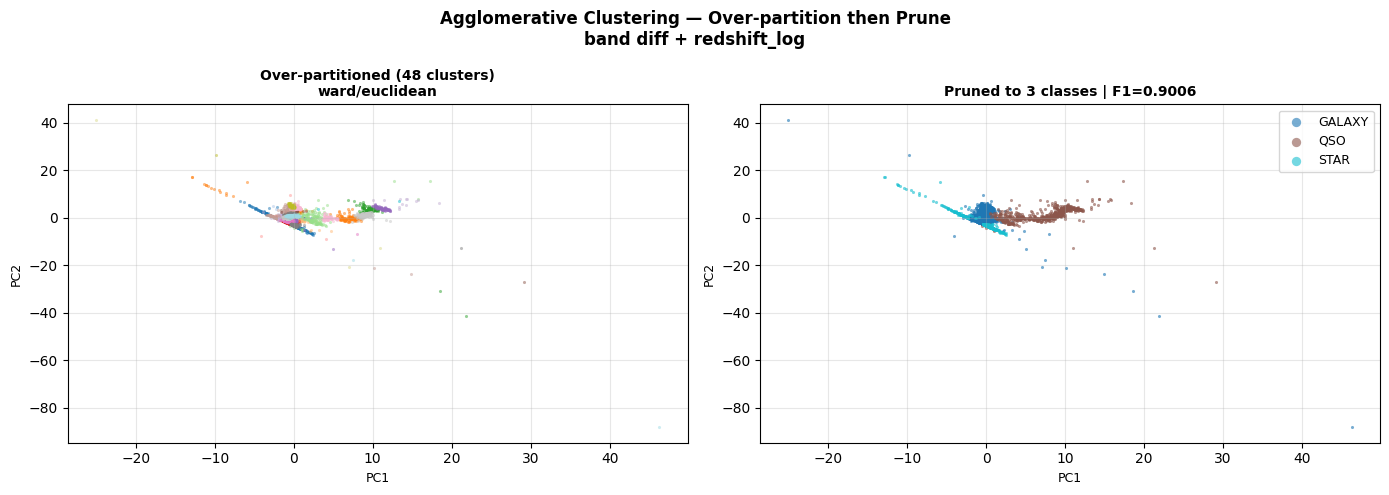

In [9]:
# Prepare Dataset (band diff + redshift_log)
df1 = X.copy()
title = 'band diff + redshift_log'

# Encode classes
le = LabelEncoder()
y_true = le.fit_transform(y)

# Helper: majority-vote each fine-grained cluster -> one of 3 class labels
def prune_clusters(y_true, labels):
    pruned = np.full_like(labels, fill_value=-1)
    for cluster in set(labels):
        mask = labels == cluster
        majority_label = mode(y_true[mask], keepdims=True).mode[0]
        pruned[mask] = majority_label
    return pruned

# Grid search: n_clusters (over-partition) x linkage x metric
n_cluster_range = list(range(3, 51))
linkage_options = ['ward', 'complete', 'average', 'single']
metric_options = ['euclidean', 'manhattan', 'cosine']

best_f1 = -1
best_cfg = None

for n_clust in n_cluster_range:
    for linkage in linkage_options:
        for metric in metric_options:
            if linkage == 'ward' and metric != 'euclidean':
                continue  # ward only supports euclidean

            hc = AgglomerativeClustering(n_clusters=n_clust, linkage=linkage, metric=metric)
            fine_labels = hc.fit_predict(df1)

            # Prune: map each fine cluster -> majority class (3 classes)
            pruned_labels = prune_clusters(y_true, fine_labels)

            f1 = f1_score(y_true, pruned_labels, average='macro')

            if f1 > best_f1:
                best_f1 = f1
                best_cfg = (n_clust, linkage, metric, fine_labels.copy(), pruned_labels.copy())

# Unpack best config
best_n, best_linkage, best_metric, best_fine_labels, best_pruned_labels = best_cfg

# Save the best model
os.makedirs('../models', exist_ok=True)
hc_best = AgglomerativeClustering(n_clusters=best_n, linkage=best_linkage, metric=best_metric)
hc_best.fit(df1)
joblib.dump(hc_best, '../models/hierarchical_model.pkl')
print(f"Model saved: n_clusters={best_n}, linkage={best_linkage}, metric={best_metric}")

# Final evaluation metrics (on pruned 3-class labels)
f1  = f1_score(y_true, best_pruned_labels, average='macro')
ari = adjusted_rand_score(y_true, best_pruned_labels)
nmi = normalized_mutual_info_score(y_true, best_pruned_labels)
sil = silhouette_score(df1, best_pruned_labels)
ch  = calinski_harabasz_score(df1, best_pruned_labels)
db_index = davies_bouldin_score(df1, best_pruned_labels)

print(f"\n{title}: n_clusters={best_n}, linkage={best_linkage}, metric={best_metric}")
print(f"\nF1 (macro):          {f1:.4f}")
print(f"ARI:                 {ari:.4f}")
print(f"NMI:                 {nmi:.4f}")
print(f"Silhouette:          {sil:.4f}")
print(f"Calinski-Harabasz:   {ch:.4f}")
print(f"Davies-Bouldin:      {db_index:.4f}")

# Cluster composition after pruning
le_classes = le.classes_
unique, counts = np.unique(best_pruned_labels, return_counts=True)
print(f"\n{title} — Class Composition (after pruning)")
print("─" * 50)
for lbl, cnt in zip(unique, counts):
    print(f"  {le_classes[lbl]:>6}: {cnt:>5} points ({cnt/len(best_pruned_labels)*100:.1f}%)")

# Fine-grained cluster composition (before pruning)
fine_unique, fine_counts = np.unique(best_fine_labels, return_counts=True)
print(f"\nFine-grained clusters (n={best_n}) before pruning:")
print("─" * 50)
for lbl, cnt in zip(fine_unique, fine_counts):
    majority = mode(y_true[best_fine_labels == lbl], keepdims=True).mode[0]
    print(f"  Cluster {lbl:>2} -> {le_classes[majority]:>6}: {cnt:>5} points ({cnt/len(best_fine_labels)*100:.1f}%)")

# Visualisation (PCA 2D) — pruned labels
X2d = PCA(n_components=2, random_state=42).fit_transform(df1)
cmap = plt.cm.get_cmap('tab10', len(le_classes))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fine-grained clusters
ax = axes[0]
fine_cmap = plt.cm.get_cmap('tab20', best_n)
for k in sorted(set(best_fine_labels)):
    mask_k = best_fine_labels == k
    ax.scatter(X2d[mask_k, 0], X2d[mask_k, 1], c=[fine_cmap(k)], s=5, alpha=0.5, linewidths=0)
ax.set_title(f'Over-partitioned ({best_n} clusters)\n{best_linkage}/{best_metric}', fontsize=10, fontweight='bold')
ax.set_xlabel('PC1', fontsize=9)
ax.set_ylabel('PC2', fontsize=9)
ax.grid(True, alpha=0.3)

# Right: pruned to 3 classes
ax = axes[1]
for lbl in sorted(set(best_pruned_labels)):
    mask_k = best_pruned_labels == lbl
    ax.scatter(X2d[mask_k, 0], X2d[mask_k, 1], c=[cmap(lbl)], s=5, alpha=0.6,
               label=le_classes[lbl], linewidths=0)
ax.set_title(f'Pruned to 3 classes | F1={f1:.4f}', fontsize=10, fontweight='bold')
ax.set_xlabel('PC1', fontsize=9)
ax.set_ylabel('PC2', fontsize=9)
ax.legend(fontsize=9, markerscale=3)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Agglomerative Clustering — Over-partition then Prune\n{title}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The over-partition-then-prune strategy leverages the full hierarchical structure of agglomerative clustering. By fitting with a larger n_clusters, the algorithm captures finer-grained local groupings that more faithfully follow the natural density contours of each class. Majority-vote consolidation then collapses these fine clusters back to the 3 target classes.

This two-stage approach typically outperforms directly constraining to 3 clusters because:
- Rare classes (QSO, STAR) that overlap with GALAXY can be captured in dedicated sub-clusters before merging.
- The pruning step effectively acts as a soft boundary correction — boundary points misassigned under a coarse 3-cluster fit may be correctly captured when sub-clusters are more tightly fitted.

The side-by-side PCA plot shows the over-partitioned state (left) versus the final 3-class assignment after pruning (right). The fine-grained cluster breakdown also shows which sub-clusters were merged into each final class, providing interpretability into the hierarchy.